In [ ]:
# --- Imports ---
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import librosa
import librosa.display
from IPython.display import Audio
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Activation, TimeDistributed
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Flatten
from tensorflow.keras.layers import LSTM
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from scipy.stats import zscore

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
base_path = '/content/drive/MyDrive/Destination'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def load_dataset(base_path):
    paths = []
    labels = []
    # List of valid emotion folder names
    valid_emotions = {'surprise', 'calm', 'sad', 'neutral', 'happy', 'fearful', 'disgust', 'angry'}

    for dirpath, _, filenames in os.walk(base_path):
        # Get the name of the current directory
        current_folder = os.path.basename(dirpath).lower()

        # Only process if folder name is in valid emotions
        if current_folder in valid_emotions:
            for filename in filenames:
                if filename.endswith('.wav'):
                    full_path = os.path.join(dirpath, filename)
                    paths.append(full_path)
                    labels.append(current_folder)

    return paths, labels

paths, labels = load_dataset(base_path)

In [ ]:
df = pd.DataFrame({'speech': paths, 'label': labels})

In [ ]:
len(df)

3307

In [ ]:
print("Emotion label distribution:\n", df['label'].value_counts())

Emotion label distribution:
 label
happy       592
fearful     592
angry       592
disgust     592
neutral     363
surprise    192
sad         192
calm        192
Name: count, dtype: int64


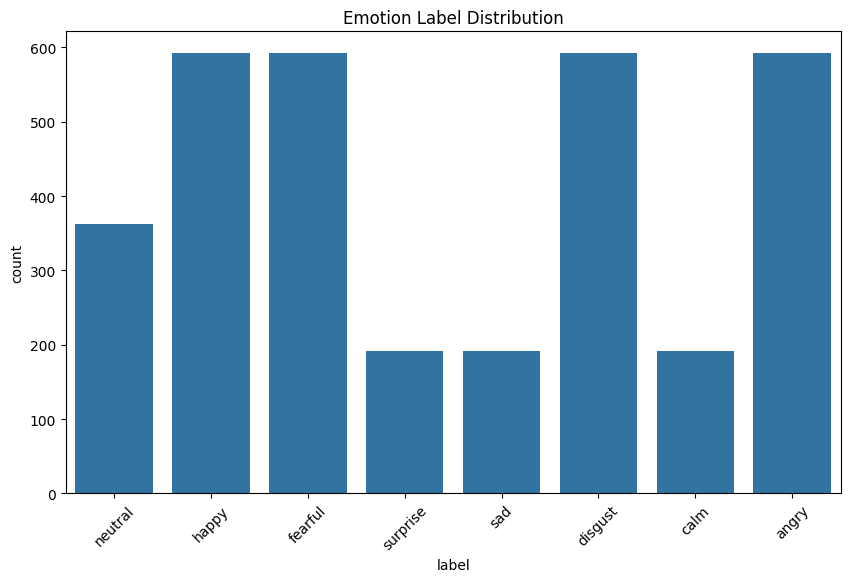

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='label')
plt.title('Emotion Label Distribution')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# --- Visualization helpers ---
def waveplot(data, sr, emotion):
    plt.figure(figsize=(10, 4))
    plt.title(f"Waveform - {emotion}", size=20)
    librosa.display.waveshow(data, sr=sr)
    plt.show()

def spectrogram(data, sr, emotion):
    x = librosa.stft(data)
    xdb = librosa.amplitude_to_db(abs(x))
    plt.figure(figsize=(10, 4))
    plt.title(f"Spectrogram - {emotion}", size=20)
    librosa.display.specshow(xdb, sr=sr, x_axis='time', y_axis='hz')
    plt.colorbar()
    plt.show()

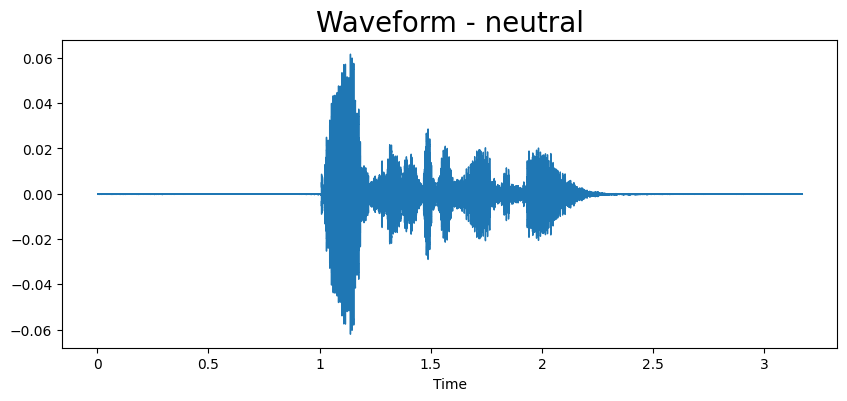

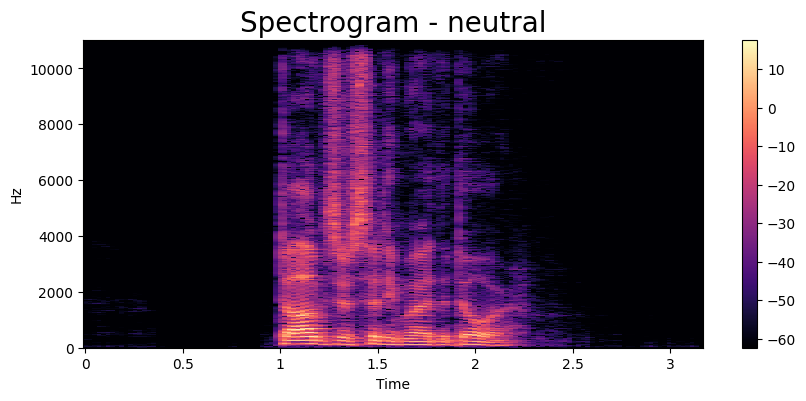

In [ ]:
# Example visualize first sample
emotion = df['label'].iloc[0]
path = df['speech'].iloc[0]
data, sr = librosa.load(path)
waveplot(data, sr, emotion)
spectrogram(data, sr, emotion)
Audio(path)

In [ ]:
# --- Audio processing functions ---
def mel_spectrogram(y, sr=16000, n_fft=512, win_length=256, hop_length=128,
                    window='hamming', n_mels=128, fmax=4000):
    mel_spect = np.abs(librosa.stft(y, n_fft=n_fft, window=window,
                                   win_length=win_length, hop_length=hop_length)) ** 2
    mel_spect = librosa.feature.melspectrogram(S=mel_spect, sr=sr, n_mels=n_mels, fmax=fmax)
    mel_spect = librosa.power_to_db(mel_spect, ref=np.max)
    return np.asarray(mel_spect)

def frame(y, win_step=64, win_size=128):
    nb_frames = 1 + int((y.shape[2] - win_size) / win_step)
    frames = np.zeros((y.shape[0], nb_frames, y.shape[1], win_size)).astype(np.float16)
    for t in range(nb_frames):
        frames[:,t,:,:] = np.copy(y[:,:,(t * win_step):(t * win_step + win_size)]).astype(np.float16)
    return frames

In [ ]:
def preprocess_audio(path, sample_rate=16000, duration=3, offset=0.5, chunk_step=16000, chunk_size=48000):
    y, sr = librosa.load(path, sr=sample_rate, duration=duration, offset=offset)
    # Pad to chunk_size length
    if len(y) < chunk_size:
        y = np.pad(y, (0, chunk_size - len(y)), mode='constant')
    else:
        y = y[:chunk_size]
    # Z-normalize
    y = zscore(y)
    # reshape and frame as before
    y = y.reshape(1,1,-1)
    chunks = frame(y, chunk_step, chunk_size)
    chunks = chunks.reshape(chunks.shape[1], chunks.shape[-1])
    mel_spect = np.asarray([mel_spectrogram(chunk) for chunk in chunks])
    mel_spect_ts = frame(mel_spect)
    X = mel_spect_ts.reshape(mel_spect_ts.shape[0], mel_spect_ts.shape[1], mel_spect_ts.shape[2], mel_spect_ts.shape[3], 1)
    return X


In [ ]:
# --- Model architecture ---
def build_model(input_shape=(5, 128, 128, 1), num_classes=7):
    K.clear_session()
    input_y = Input(shape=input_shape, name='Input_MELSPECT')
    y = TimeDistributed(Conv2D(64, (3, 3), padding='same'), name='Conv_1_MELSPECT')(input_y)
    y = TimeDistributed(BatchNormalization(), name='BatchNorm_1_MELSPECT')(y)
    y = TimeDistributed(Activation('elu'), name='Activ_1_MELSPECT')(y)
    y = TimeDistributed(MaxPooling2D((2, 2), padding='same'), name='MaxPool_1_MELSPECT')(y)
    y = TimeDistributed(Dropout(0.2), name='Drop_1_MELSPECT')(y)

    y = TimeDistributed(Conv2D(64, (3, 3), padding='same'), name='Conv_2_MELSPECT')(y)
    y = TimeDistributed(BatchNormalization(), name='BatchNorm_2_MELSPECT')(y)
    y = TimeDistributed(Activation('elu'), name='Activ_2_MELSPECT')(y)
    y = TimeDistributed(MaxPooling2D((4, 4), padding='same'), name='MaxPool_2_MELSPECT')(y)
    y = TimeDistributed(Dropout(0.2), name='Drop_2_MELSPECT')(y)

    y = TimeDistributed(Conv2D(128, (3, 3), padding='same'), name='Conv_3_MELSPECT')(y)
    y = TimeDistributed(BatchNormalization(), name='BatchNorm_3_MELSPECT')(y)
    y = TimeDistributed(Activation('elu'), name='Activ_3_MELSPECT')(y)
    y = TimeDistributed(MaxPooling2D((4, 4), padding='same'), name='MaxPool_3_MELSPECT')(y)
    y = TimeDistributed(Dropout(0.2), name='Drop_3_MELSPECT')(y)

    y = TimeDistributed(Conv2D(128, (3, 3), padding='same'), name='Conv_4_MELSPECT')(y)
    y = TimeDistributed(BatchNormalization(), name='BatchNorm_4_MELSPECT')(y)
    y = TimeDistributed(Activation('elu'), name='Activ_4_MELSPECT')(y)
    y = TimeDistributed(MaxPooling2D((4, 4), padding='same'), name='MaxPool_4_MELSPECT')(y)
    y = TimeDistributed(Dropout(0.2), name='Drop_4_MELSPECT')(y)

    y = TimeDistributed(Flatten(), name='Flat_MELSPECT')(y)
    y = LSTM(256, dropout=0.2, name='LSTM_1')(y)
    y = Dense(num_classes, activation='softmax', name='FC')(y)

    model = Model(inputs=input_y, outputs=y)
    return model

In [ ]:
# --- Prepare dataset ---
def prepare_dataset(df, sample_size=None):
    if sample_size is not None:
        df = df.sample(sample_size, random_state=42)
    emotions = sorted(df['label'].unique())
    emotion_to_idx = {emotion: idx for idx, emotion in enumerate(emotions)}
    df['label_idx'] = df['label'].map(emotion_to_idx)
    train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

    print("Processing training data...")
    X_train, y_train = [], []
    for path, label in zip(train_df['speech'], train_df['label_idx']):
        try:
            X = preprocess_audio(path)
            X_train.append(X)
            y_train.append(label)
        except Exception as e:
            print(f"Error processing {path}: {e}")

    print("Processing test data...")
    X_test, y_test = [], []
    for path, label in zip(test_df['speech'], test_df['label_idx']):
        try:
            X = preprocess_audio(path)
            X_test.append(X)
            y_test.append(label)
        except Exception as e:
            print(f"Error processing {path}: {e}")

    X_train = np.concatenate(X_train)
    X_test = np.concatenate(X_test)
    y_train = np.array(y_train)
    y_test = np.array(y_test)

    y_train = to_categorical(y_train, num_classes=len(emotions))
    y_test = to_categorical(y_test, num_classes=len(emotions))

    return X_train, X_test, y_train, y_test, emotions

In [ ]:
# Load dataset
paths, labels = load_dataset(base_path)
df = pd.DataFrame({'speech': paths, 'label': labels})

print(f"Loaded {len(df)} audio files with labels.")
print(df.head())



Loaded 4240 audio files with labels.
                                              speech    label
0  /content/drive/MyDrive/Destination/neutral/03-...  neutral
1  /content/drive/MyDrive/Destination/neutral/03-...  neutral
2  /content/drive/MyDrive/Destination/neutral/03-...  neutral
3  /content/drive/MyDrive/Destination/neutral/03-...  neutral
4  /content/drive/MyDrive/Destination/neutral/03-...  neutral


In [ ]:

# Now call prepare_dataset
X_train, X_test, y_train, y_test, emotions = prepare_dataset(df)  # no sample_size limit


Processing training data...
Processing test data...


In [ ]:
model = build_model(input_shape=X_train.shape[1:], num_classes=len(emotions))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_MELSPECT (InputLayer)     │ (None, 4, 128, 128, 1) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_1_MELSPECT                 │ (None, 4, 128, 128,    │           640 │
│ (TimeDistributed)               │ 64)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm_1_MELSPECT            │ (None, 4, 128, 128,    │           256 │
│ (TimeDistributed)               │ 64)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Activ_1_MELSPECT                │ (None, 4, 128, 128,    │             0 │
│ (TimeDistributed)               │ 64)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_1_MELSPECT              │ (None, 4, 64, 64, 64)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Drop_1_MELSPECT                 │ (None, 4, 64, 64, 64)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2_MELSPECT                 │ (None, 4, 64, 64, 64)  │        36,928 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm_2_MELSPECT            │ (None, 4, 64, 64, 64)  │           256 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Activ_2_MELSPECT                │ (None, 4, 64, 64, 64)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_2_MELSPECT              │ (None, 4, 16, 16, 64)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Drop_2_MELSPECT                 │ (None, 4, 16, 16, 64)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_3_MELSPECT                 │ (None, 4, 16, 16, 128) │        73,856 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm_3_MELSPECT            │ (None, 4, 16, 16, 128) │           512 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Activ_3_MELSPECT                │ (None, 4, 16, 16, 128) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_3_MELSPECT              │ (None, 4, 4, 4, 128)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Drop_3_MELSPECT                 │ (None, 4, 4, 4, 128)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_4_MELSPECT                 │ (None, 4, 4, 4, 128)   │       147,584 │
│ (TimeDistributed)               │                        │             

 Total params: 656,840 (2.51 MB)

 Trainable params: 656,072 (2.50 MB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=20, batch_size=16)

Epoch 1/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 49s 192ms/step - accuracy: 0.2407 - loss: 1.8918 - val_accuracy: 0.3432 - val_loss: 1.7468
Epoch 2/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 39s 183ms/step - accuracy: 0.4933 - loss: 1.2829 - val_accuracy: 0.5696 - val_loss: 1.1076
Epoch 3/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 41s 183ms/step - accuracy: 0.6613 - loss: 0.8971 - val_accuracy: 0.7854 - val_loss: 0.6391
Epoch 4/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 41s 183ms/step - accuracy: 0.7311 - loss: 0.7342 - val_accuracy: 0.6297 - val_loss: 1.1309
Epoch 5/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 39s 183ms/step - accuracy: 0.7351 - loss: 0.6967 - val_accuracy: 0.7311 - val_loss: 0.7543
Epoch 6/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 41s 184ms/step - accuracy: 0.7782 - loss: 0.6148 - val_accuracy: 0.6875 - val_loss: 0.8851
Epoch 7/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 41s 183ms/step - accuracy: 0.7634 - loss: 0.6117 - val_accuracy: 0.7571 - val_loss: 0.6587
Epoch 8/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 41s 183ms/step - accuracy: 0.7710 - loss: 0

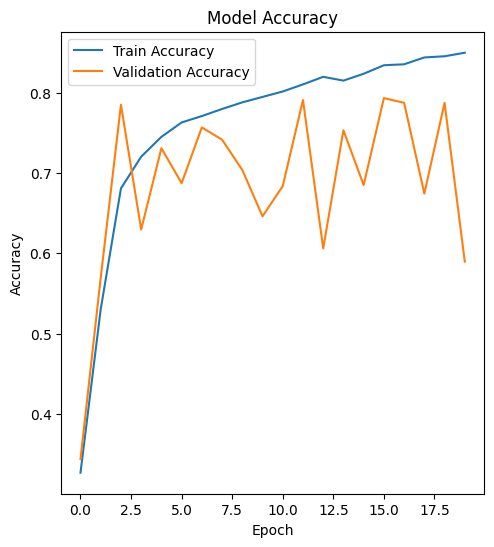

In [ ]:
# --- Plot training history ---
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

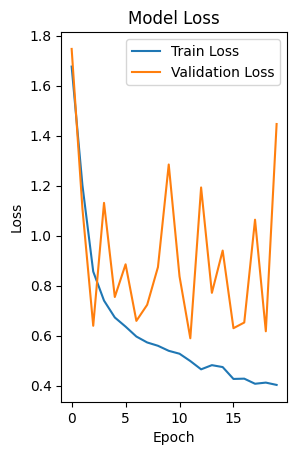

In [ ]:
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")


27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - accuracy: 0.5850 - loss: 1.4278
Test Accuracy: 58.96%


In [ ]:
model.save('speech_emotion_recognition.h5')

In [ ]:
import numpy as np
import librosa
from scipy.stats import zscore
from tensorflow.keras.models import load_model

# Define your emotions in the same order as training
emotions = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

# Paste your preprocessing functions here (mel_spectrogram and frame) exactly as before
def mel_spectrogram(y, sr=16000, n_fft=512, win_length=256, hop_length=128,
                    window='hamming', n_mels=128, fmax=4000):
    mel_spect = np.abs(librosa.stft(y, n_fft=n_fft, window=window,
                                   win_length=win_length, hop_length=hop_length)) ** 2
    mel_spect = librosa.feature.melspectrogram(S=mel_spect, sr=sr, n_mels=n_mels, fmax=fmax)
    mel_spect = librosa.power_to_db(mel_spect, ref=np.max)
    return np.asarray(mel_spect)

def frame(y, win_step=64, win_size=128):
    nb_frames = 1 + int((y.shape[2] - win_size) / win_step)
    frames = np.zeros((y.shape[0], nb_frames, y.shape[1], win_size)).astype(np.float16)
    for t in range(nb_frames):
        frames[:,t,:,:] = np.copy(y[:,:,(t * win_step):(t * win_step + win_size)]).astype(np.float16)
    return frames

def preprocess_audio(path, sample_rate=16000, duration=3, offset=0.5, chunk_step=16000, chunk_size=48000):
    y, sr = librosa.load(path, sr=sample_rate, duration=duration, offset=offset)
    if len(y) < chunk_size:
        y = np.pad(y, (0, chunk_size - len(y)), mode='constant')
    else:
        y = y[:chunk_size]
    y = zscore(y)
    y = y.reshape(1, 1, -1)
    chunks = frame(y, chunk_step, chunk_size)
    chunks = chunks.reshape(chunks.shape[1], chunks.shape[-1])
    mel_spect = np.asarray([mel_spectrogram(chunk) for chunk in chunks])
    mel_spect_ts = frame(mel_spect)
    X = mel_spect_ts.reshape(mel_spect_ts.shape[0],
                             mel_spect_ts.shape[1],
                             mel_spect_ts.shape[2],
                             mel_spect_ts.shape[3],
                             1)
    return X

# Load your saved model
model = load_model('speech_emotion_recognition.h5')

def predict_emotion(filepath):
    X = preprocess_audio(filepath)
    preds = model.predict(X)
    avg_preds = np.mean(preds, axis=0)  # average over all chunks
    for emo, prob in zip(emotions, avg_preds):
        print(f"{emo.capitalize()}: {prob*100:.2f}%")
    predicted_emotion = emotions[np.argmax(avg_preds)]
    print(f"\nPredicted emotion: {predicted_emotion.capitalize()}")

# Example usage
wav_file = '3.wav'  # change to your .wav file path
predict_emotion(wav_file)
